In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#### importamos los datos 
data= pd.read_csv('barcelona_super_limpio.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18912 entries, 0 to 18911
Data columns (total 78 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            18912 non-null  int64  
 1   listing_url                                   18912 non-null  object 
 2   scrape_id                                     18912 non-null  int64  
 3   last_scraped                                  18912 non-null  object 
 4   source                                        18912 non-null  object 
 5   name                                          18912 non-null  object 
 6   description                                   18912 non-null  object 
 7   neighborhood_overview                         18912 non-null  object 
 8   picture_url                                   18912 non-null  object 
 9   host_id                                       18912 non-null 

In [4]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum().sum()
valores_nulos

0

In [12]:
###no usamos estas variables ya que son los identificadores 
cualitativasnousadas= [["id", "scrape_id", "host_id"]]

In [9]:
# Variables cuantitativas
cuantitativas = data[[
    
    "host_response_rate", "host_acceptance_rate",
    "host_listings_count", "host_total_listings_count",
    "latitude", "longitude", "accommodates",
    "bathrooms", "bedrooms", "beds", "price",
    "minimum_nights", "maximum_nights",
    "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
    "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    "availability_30", "availability_60",
    "availability_90", "availability_365",
    "number_of_reviews", "number_of_reviews_ltm",
    "number_of_reviews_l30d", "availability_eoy",
    "number_of_reviews_ly", "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "reviews_per_month"
]]

# Variables cualitativas
cualitativas = data[[
    "listing_url", "last_scraped", "source", "name", "description",
    "neighborhood_overview", "picture_url", "host_url", "host_name",
    "host_since", "host_location", "host_about", "host_response_time",
    "host_is_superhost", "host_thumbnail_url", "host_picture_url",
    "host_neighbourhood", "host_verifications", "host_has_profile_pic",
    "host_identity_verified", "neighbourhood", "neighbourhood_cleansed",
    "neighbourhood_group_cleansed", "property_type", "room_type",
    "bathrooms_text", "amenities", "calendar_last_scraped",
    "has_availability", "first_review", "last_review",
    "license", "instant_bookable"
]]


<Figure size 1500x800 with 0 Axes>

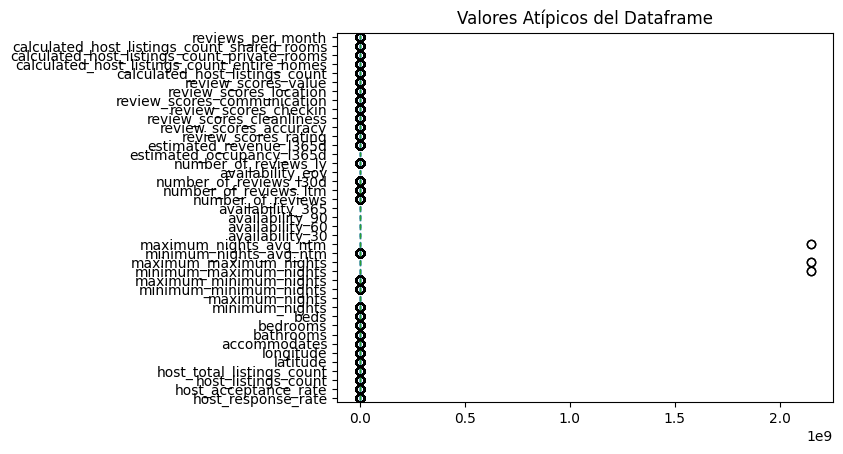

In [10]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

**PROCEDIMIENTO "DESVIACIÓN ESTÁNDAR" PARA ELIMINAR OUTLIERS EN DATAFRAME**

In [14]:
###remplazar la variable price 
cuantitativas['price'] = cuantitativas['price'].replace('[\$,]', '', regex=True).astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/var/folders/6c/rr21_80s11n3cvrghbnb5mz00000gn/T/ipykernel_1522/2892341529.py:2: SyntaxWarning: invalid escape sequence '\$'
  cuantitativas['price'] = cuantitativas['price'].replace('[\$,]', '', regex=True).astype(float)
/var/folders/6c/rr21_80s11n3cvrghbnb5mz00000gn/T/ipykernel_1522/2892341529.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cuantitativas['price'] = cuantitativas['price'].replace('[\$,]', '', regex=True).astype(float)


In [15]:
#Método aplicando desviación estandar. Encuentro los valores extremos
#desv est detecta menos datos outliers que interquartilicos.
y=cuantitativas
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido host_response_rate                              1.399862e+02
host_acceptance_rate                            1.534824e+02
host_listings_count                             6.033557e+02
host_total_listings_count                       7.260921e+02
latitude                                        4.143443e+01
longitude                                       2.220395e+00
accommodates                                    1.019810e+01
bathrooms                                       3.686242e+00
bedrooms                                        5.662512e+00
beds                                            8.619424e+00
price                                           1.340844e+03
minimum_nights                                  1.054782e+02
maximum_nights                                  1.720448e+03
minimum_minimum_nights                          9.243054e+01
maximum_minimum_nights                          2.068703e+02
minimum_maximum_nights                          6.647764e+0

In [16]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data3= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data3

,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,96.0,91.0,44.0,46.0,41.405560,2.172620,8.0,2.0,3.0,6.0,...,4.530000,4.620000,4.600000,4.810000,4.280000,28.0,28.0,0.0,0.0,0.330000
1,100.0,96.0,6.0,9.0,41.412432,2.219750,5.0,2.0,3.0,4.0,...,4.900000,4.940000,4.990000,4.650000,4.680000,1.0,1.0,0.0,0.0,0.510000
2,100.0,100.0,3.0,15.0,41.405660,2.170150,6.0,1.5,2.0,3.0,...,4.380000,4.880000,4.890000,4.890000,4.470000,3.0,3.0,0.0,0.0,0.870000
3,80.0,94.0,5.0,5.0,41.380620,2.175170,2.0,1.0,1.0,1.0,...,4.550000,4.680000,4.680000,4.730000,4.230000,3.0,3.0,0.0,0.0,0.140000
4,87.0,28.0,356.0,565.0,41.376400,2.191020,3.0,1.0,1.0,3.0,...,4.000000,NaN,3.670000,5.000000,4.000000,355.0,NaN,0.0,0.0,0.020000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18907,100.0,79.0,224.0,262.0,41.399220,2.178950,5.0,2.0,3.0,5.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,205.0,205.0,0.0,0.0,1.454379
18908,100.0,79.0,224.0,262.0,41.399790,2.180350,6.0,2.0,3.0,6.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,205.0,205.0,0.0,0.0,1.454379
18909,100.0,79.0,224.0,262.0,41.399390,2.180520,6.0,2.0,3.0,6.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,205.0,205.0,0.0,0.0,1.454379
18910,100.0,79.0,224.0,262.0,41.400813,2.180756,5.0,1.0,3.0,5.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,205.0,205.0,0.0,0.0,1.454379


In [17]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data3.isnull().sum()
valores_nulos

host_response_rate                              525
host_acceptance_rate                            664
host_listings_count                             542
host_total_listings_count                       551
latitude                                        187
longitude                                        52
accommodates                                    229
bathrooms                                       308
bedrooms                                        263
beds                                            214
price                                           189
minimum_nights                                   93
maximum_nights                                    0
minimum_minimum_nights                           94
maximum_minimum_nights                          315
minimum_maximum_nights                            2
maximum_maximum_nights                            2
minimum_nights_avg_ntm                          203
maximum_nights_avg_ntm                            2
availability

In [18]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data_clean=data3.copy()
data_clean=data_clean.fillna(round(data3.mean(),1))
data_clean

,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,96.0,91.0,44.0,46.0,41.405560,2.172620,8.0,2.0,3.0,6.0,...,4.530000,4.620000,4.600000,4.810000,4.280000,28.0,28.0,0.0,0.0,0.330000
1,100.0,96.0,6.0,9.0,41.412432,2.219750,5.0,2.0,3.0,4.0,...,4.900000,4.940000,4.990000,4.650000,4.680000,1.0,1.0,0.0,0.0,0.510000
2,100.0,100.0,3.0,15.0,41.405660,2.170150,6.0,1.5,2.0,3.0,...,4.380000,4.880000,4.890000,4.890000,4.470000,3.0,3.0,0.0,0.0,0.870000
3,80.0,94.0,5.0,5.0,41.380620,2.175170,2.0,1.0,1.0,1.0,...,4.550000,4.680000,4.680000,4.730000,4.230000,3.0,3.0,0.0,0.0,0.140000
4,87.0,28.0,356.0,565.0,41.376400,2.191020,3.0,1.0,1.0,3.0,...,4.000000,4.800000,3.670000,5.000000,4.000000,355.0,20.8,0.0,0.0,0.020000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18907,100.0,79.0,224.0,262.0,41.399220,2.178950,5.0,2.0,3.0,5.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,205.0,205.0,0.0,0.0,1.454379
18908,100.0,79.0,224.0,262.0,41.399790,2.180350,6.0,2.0,3.0,6.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,205.0,205.0,0.0,0.0,1.454379
18909,100.0,79.0,224.0,262.0,41.399390,2.180520,6.0,2.0,3.0,6.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,205.0,205.0,0.0,0.0,1.454379
18910,100.0,79.0,224.0,262.0,41.400813,2.180756,5.0,1.0,3.0,5.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,205.0,205.0,0.0,0.0,1.454379


In [ ]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

# Concatenamos solo los dataframes
Desvst_clean = pd.concat([cualitativas, data_clean], axis=1)

# Eliminamos las columnas no usadas si están presentes
for col in cualitativasnousadas[0]:
	if col in Desvst_clean.columns:
		Desvst_clean = Desvst_clean.drop(columns=col)

Desvst_clean


,listing_url,last_scraped,source,name,description,neighborhood_overview,picture_url,host_url,host_name,host_since,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,https://www.airbnb.com/rooms/18674,2025-06-21,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,Apartment in Barcelona located in the heart of...,https://a0.muscache.com/pictures/13031453/413c...,https://www.airbnb.com/users/show/71615,Mireia Maria,2010-01-19,...,4.530000,4.620000,4.600000,4.810000,4.280000,28.0,28.0,0.0,0.0,0.330000
1,https://www.airbnb.com/rooms/23197,2025-06-23,city scrape,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",Beautiful and Spacious Apartment with Large Te...,"Strategically located in the Parc del Fòrum, a...",https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/users/show/90417,Etain (Marnie),2010-03-09,...,4.900000,4.940000,4.990000,4.650000,4.680000,1.0,1.0,0.0,0.0,0.510000
2,https://www.airbnb.com/rooms/32711,2025-06-22,city scrape,Sagrada Familia area - Còrsega 1,A lovely two bedroom apartment only 250 m from...,What's nearby <br />This apartment is located...,https://a0.muscache.com/pictures/357b25e4-f414...,https://www.airbnb.com/users/show/135703,Nick,2010-05-31,...,4.380000,4.880000,4.890000,4.890000,4.470000,3.0,3.0,0.0,0.0,0.870000
3,https://www.airbnb.com/rooms/34241,2025-06-22,city scrape,Stylish Top Floor Apartment - Ramblas Plaza Real,Located in close proximity to Plaza Real and L...,No Data,https://a0.muscache.com/pictures/2437facc-2fe7...,https://www.airbnb.com/users/show/73163,Andres,2010-01-24,...,4.550000,4.680000,4.680000,4.730000,4.230000,3.0,3.0,0.0,0.0,0.140000
4,https://www.airbnb.com/rooms/347824,2025-06-22,city scrape,"Ideal Happy Location Barceloneta Beach, Old Town!",Please send us a message to confirm availabili...,No Data,https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/users/show/1447144,Acomodis Apartments,2011-11-27,...,4.000000,4.800000,3.670000,5.000000,4.000000,355.0,20.8,0.0,0.0,0.020000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18907,https://www.airbnb.com/rooms/1440378586135901437,2025-06-26,city scrape,AB Marina Apartment I-II,Rental registration number (NRA): ESHFTU000008...,"Eixample is Catalan for 'extension', meaning a...",https://a0.muscache.com/pictures/prohost-api/H...,https://www.airbnb.com/users/show/4459553,AB Apartment Barcelona,2012-12-21,...,4.621006,4.722626,4.720793,4.752836,4.464138,205.0,205.0,0.0,0.0,1.454379
18908,https://www.airbnb.com/rooms/1440379191108051829,2025-06-21,city scrape,AB Marina Apartment III-I,Rental registration number (NRA): ESHFTU000008...,"Eixample is Catalan for 'extension', meaning a...",https://a0.muscache.com/pictures/prohost-api/H...,https://www.airbnb.com/users/show/4459553,AB Apartment Barcelona,2012-12-21,...,4.621006,4.722626,4.720793,4.752836,4.464138,205.0,205.0,0.0,0.0,1.454379
18909,https://www.airbnb.com/rooms/1440379869744969989,2025-06-21,city scrape,AB Marina Apartment IV-I,Rental registration number (NRA): ESHFTU000008...,"Eixample is Catalan for 'extension', meaning a...",https://a0.muscache.com/pictures/prohost-api/H...,https://www.airbnb.com/users/show/4459553,AB Apartment Barcelona,2012-12-21,...,4.621006,4.722626,4.720793,4.752836,4.464138,205.0,205.0,0.0,0.0,1.454379
18910,https://www.airbnb.com/rooms/1440380503685655376,2025-06-23,city scrape,AB Sagrada Familia Views VIII-I,This three-bedroom apartment is found in the E...,"Eixample is Catalan for 'extension', meaning a...",https://a0.muscache.com/pictures/prohost-api/H...,https://www.airbnb.com/users/show/4459553,AB Apartment Barcelona,2012-12-21,...,4.621006,4.722626,4.720793,4

In [23]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data_clean.isnull().sum().sum()
valores_nulos

0

In [24]:
#Convertir a csv
Desvst_clean.to_csv("Data_desvestbarcelona.csv")

**PROCEDIMIENTO "CUANTILES" PARA SUSTITUIR OUTLIERS EN DATAFRAME**

In [25]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido host_response_rate                                110.890971
host_acceptance_rate                              121.500000
host_listings_count                               114.500000
host_total_listings_count                         203.000000
latitude                                           41.432276
longitude                                           2.209802
accommodates                                        7.000000
bathrooms                                           3.500000
bedrooms                                            3.500000
beds                                                6.000000
price                                             528.000000
minimum_nights                                     76.000000
maximum_nights                                   2317.500000
minimum_minimum_nights                             76.000000
maximum_minimum_nights                             75.500000
minimum_maximum_nights                           2409.00000

In [26]:
#Obtenemos datos limpios del Dataframe
data3_iqr= cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data3_iqr

,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,96.0,91.0,44.0,46.0,41.405560,2.172620,NaN,2.0,3.0,6.0,...,4.530000,4.620000,4.600000,4.810000,4.280000,28.0,28.0,0.0,0.0,0.330000
1,100.0,96.0,6.0,9.0,41.412432,NaN,5.0,2.0,3.0,4.0,...,4.900000,4.940000,4.990000,4.650000,4.680000,1.0,1.0,0.0,0.0,0.510000
2,100.0,100.0,3.0,15.0,41.405660,2.170150,6.0,1.5,2.0,3.0,...,4.380000,4.880000,4.890000,4.890000,4.470000,3.0,3.0,0.0,0.0,0.870000
3,NaN,94.0,5.0,5.0,41.380620,2.175170,2.0,1.0,1.0,1.0,...,4.550000,4.680000,4.680000,4.730000,4.230000,3.0,3.0,0.0,0.0,0.140000
4,87.0,NaN,NaN,NaN,41.376400,2.191020,3.0,1.0,1.0,3.0,...,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,0.0,0.0,0.020000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18907,100.0,79.0,NaN,NaN,41.399220,2.178950,5.0,2.0,3.0,5.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,NaN,NaN,0.0,0.0,1.454379
18908,100.0,79.0,NaN,NaN,41.399790,2.180350,6.0,2.0,3.0,6.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,NaN,NaN,0.0,0.0,1.454379
18909,100.0,79.0,NaN,NaN,41.399390,2.180520,6.0,2.0,3.0,6.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,NaN,NaN,0.0,0.0,1.454379
18910,100.0,79.0,NaN,NaN,41.400813,2.180756,5.0,1.0,3.0,5.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,NaN,NaN,0.0,0.0,1.454379


In [27]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data3_iqr.isnull().sum()
valores_nulos

host_response_rate                              2018
host_acceptance_rate                            2451
host_listings_count                             3715
host_total_listings_count                       2640
latitude                                         224
longitude                                        438
accommodates                                     970
bathrooms                                        308
bedrooms                                        1247
beds                                             540
price                                            817
minimum_nights                                   196
maximum_nights                                     0
minimum_minimum_nights                           177
maximum_minimum_nights                           718
minimum_maximum_nights                             2
maximum_maximum_nights                             2
minimum_nights_avg_ntm                           359
maximum_nights_avg_ntm                        

In [28]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data4_iqr=data3_iqr.copy()
data4_iqr=data4_iqr.fillna(round(data3_iqr.median(),1))
data4_iqr

,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,96.0,91.0,44.0,46.0,41.405560,2.172620,2.0,2.0,3.0,6.0,...,4.530000,4.620000,4.600000,4.810000,4.280000,28.0,28.0,0.0,0.0,0.330000
1,100.0,96.0,6.0,9.0,41.412432,2.200000,5.0,2.0,3.0,4.0,...,4.900000,4.940000,4.990000,4.650000,4.680000,1.0,1.0,0.0,0.0,0.510000
2,100.0,100.0,3.0,15.0,41.405660,2.170150,6.0,1.5,2.0,3.0,...,4.380000,4.880000,4.890000,4.890000,4.470000,3.0,3.0,0.0,0.0,0.870000
3,100.0,94.0,5.0,5.0,41.380620,2.175170,2.0,1.0,1.0,1.0,...,4.550000,4.680000,4.680000,4.730000,4.230000,3.0,3.0,0.0,0.0,0.140000
4,87.0,97.0,5.0,8.0,41.376400,2.191020,3.0,1.0,1.0,3.0,...,4.700000,4.800000,4.800000,5.000000,4.500000,4.0,1.0,0.0,0.0,0.020000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18907,100.0,79.0,5.0,8.0,41.399220,2.178950,5.0,2.0,3.0,5.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,4.0,1.0,0.0,0.0,1.454379
18908,100.0,79.0,5.0,8.0,41.399790,2.180350,6.0,2.0,3.0,6.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,4.0,1.0,0.0,0.0,1.454379
18909,100.0,79.0,5.0,8.0,41.399390,2.180520,6.0,2.0,3.0,6.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,4.0,1.0,0.0,0.0,1.454379
18910,100.0,79.0,5.0,8.0,41.400813,2.180756,5.0,1.0,3.0,5.0,...,4.621006,4.722626,4.720793,4.752836,4.464138,4.0,1.0,0.0,0.0,1.454379


In [30]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data4_iqr], axis=1)

# Eliminamos las columnas no usadas si están presentes
for col in cualitativasnousadas[0]:
	if col in Datos_limpios.columns:
		Datos_limpios = Datos_limpios.drop(columns=col)

Datos_limpios

,listing_url,last_scraped,source,name,description,neighborhood_overview,picture_url,host_url,host_name,host_since,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,https://www.airbnb.com/rooms/18674,2025-06-21,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,Apartment in Barcelona located in the heart of...,https://a0.muscache.com/pictures/13031453/413c...,https://www.airbnb.com/users/show/71615,Mireia Maria,2010-01-19,...,4.530000,4.620000,4.600000,4.810000,4.280000,28.0,28.0,0.0,0.0,0.330000
1,https://www.airbnb.com/rooms/23197,2025-06-23,city scrape,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",Beautiful and Spacious Apartment with Large Te...,"Strategically located in the Parc del Fòrum, a...",https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/users/show/90417,Etain (Marnie),2010-03-09,...,4.900000,4.940000,4.990000,4.650000,4.680000,1.0,1.0,0.0,0.0,0.510000
2,https://www.airbnb.com/rooms/32711,2025-06-22,city scrape,Sagrada Familia area - Còrsega 1,A lovely two bedroom apartment only 250 m from...,What's nearby <br />This apartment is located...,https://a0.muscache.com/pictures/357b25e4-f414...,https://www.airbnb.com/users/show/135703,Nick,2010-05-31,...,4.380000,4.880000,4.890000,4.890000,4.470000,3.0,3.0,0.0,0.0,0.870000
3,https://www.airbnb.com/rooms/34241,2025-06-22,city scrape,Stylish Top Floor Apartment - Ramblas Plaza Real,Located in close proximity to Plaza Real and L...,No Data,https://a0.muscache.com/pictures/2437facc-2fe7...,https://www.airbnb.com/users/show/73163,Andres,2010-01-24,...,4.550000,4.680000,4.680000,4.730000,4.230000,3.0,3.0,0.0,0.0,0.140000
4,https://www.airbnb.com/rooms/347824,2025-06-22,city scrape,"Ideal Happy Location Barceloneta Beach, Old Town!",Please send us a message to confirm availabili...,No Data,https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/users/show/1447144,Acomodis Apartments,2011-11-27,...,4.700000,4.800000,4.800000,5.000000,4.500000,4.0,1.0,0.0,0.0,0.020000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18907,https://www.airbnb.com/rooms/1440378586135901437,2025-06-26,city scrape,AB Marina Apartment I-II,Rental registration number (NRA): ESHFTU000008...,"Eixample is Catalan for 'extension', meaning a...",https://a0.muscache.com/pictures/prohost-api/H...,https://www.airbnb.com/users/show/4459553,AB Apartment Barcelona,2012-12-21,...,4.621006,4.722626,4.720793,4.752836,4.464138,4.0,1.0,0.0,0.0,1.454379
18908,https://www.airbnb.com/rooms/1440379191108051829,2025-06-21,city scrape,AB Marina Apartment III-I,Rental registration number (NRA): ESHFTU000008...,"Eixample is Catalan for 'extension', meaning a...",https://a0.muscache.com/pictures/prohost-api/H...,https://www.airbnb.com/users/show/4459553,AB Apartment Barcelona,2012-12-21,...,4.621006,4.722626,4.720793,4.752836,4.464138,4.0,1.0,0.0,0.0,1.454379
18909,https://www.airbnb.com/rooms/1440379869744969989,2025-06-21,city scrape,AB Marina Apartment IV-I,Rental registration number (NRA): ESHFTU000008...,"Eixample is Catalan for 'extension', meaning a...",https://a0.muscache.com/pictures/prohost-api/H...,https://www.airbnb.com/users/show/4459553,AB Apartment Barcelona,2012-12-21,...,4.621006,4.722626,4.720793,4.752836,4.464138,4.0,1.0,0.0,0.0,1.454379
18910,https://www.airbnb.com/rooms/1440380503685655376,2025-06-23,city scrape,AB Sagrada Familia Views VIII-I,This three-bedroom apartment is found in the E...,"Eixample is Catalan for 'extension', meaning a...",https://a0.muscache.com/pictures/prohost-api/H...,https://www.airbnb.com/users/show/4459553,AB Apartment Barcelona,2012-12-21,...,4.621006,4.722626,4.720793,4.752836,4.46413

In [31]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

listing_url                                     0
last_scraped                                    0
source                                          0
name                                            0
description                                     0
                                               ..
calculated_host_listings_count                  0
calculated_host_listings_count_entire_homes     0
calculated_host_listings_count_private_rooms    0
calculated_host_listings_count_shared_rooms     0
reviews_per_month                               0
Length: 75, dtype: int64

In [32]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Datos_limpiosbarcelonaoutliers.csv")